
* Based on [Scikit tutorial](https://scikit-learn.org/stable/auto_examples/svm/plot_separating_hyperplane.html) and [this one on the SGDClassifier class](https://scikit-learn.org/stable/auto_examples/linear_model/plot_sgd_separating_hyperplane.html#sphx-glr-auto-examples-linear-model-plot-sgd-separating-hyperplane-py)
* Example SVM look at [this Github notebook](https://github.com/alirezadir/Machine-Learning-Interviews/blob/main/src/MLC/notebooks/svm.ipynb)
* Good summary from Stanford course [CS229](https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-supervised-learning#svm) and a less well explained but seemingly correct [blog post](https://medium.com/@gallettilance/support-vector-machines-16241417ee6d)


Support Vector Machines, SVMs, are a type of linear model which aims to find a decision boundary with the largest margin of separation between data points. This decision boundary is a hyperplane, a line in 2D and a plane in 3D, where the margin of separation is the distance between the hyperplane and support vectors, points either side of the decision boundary who's distance from the hyperplane give the margin of separation.

This can be seen in the image below from [CS229](https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-supervised-learning#svm), the solid line is the decision boundary, and the margin shown by the dotted line. "w" is the normal to the hyperplane also descirbed by the weights of the linear classifier


<div align="center">
<img src="https://stanford.edu/~shervine/teaching/cs-229/illustrations/svm-en.png?d23456fe589935f26cf32c1664c90851" width="500"/>
</div>


The kernel trick can be applied to this model by projecting the parameters "w" and the inputs "x" into a higher dimensional space for linear separation before projecting back. This can be seen in the image below from [this blog](https://medium.com/@Suraj_Yadav/what-is-kernel-trick-in-svm-interview-questions-related-to-kernel-trick-97674401c48d), it is probably the RBG kernel.
<div align="center">
<img src="./svm_kernel_trick.jpeg" width="500"/>
</div>

SVMs are fundamentally linear classifiers, somehow  you can train a Linear Regression model with a Hinge Loss to get an SVM, not sure how this works out. You can see this from Sci-Kits [SGDClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html) with a Hinge loss.

In [16]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import svm
from sklearn.datasets import make_blobs
from sklearn.inspection import DecisionBoundaryDisplay

In [2]:
# we create 40 separable points
X, y = make_blobs(n_samples=80, centers=2, random_state=6)

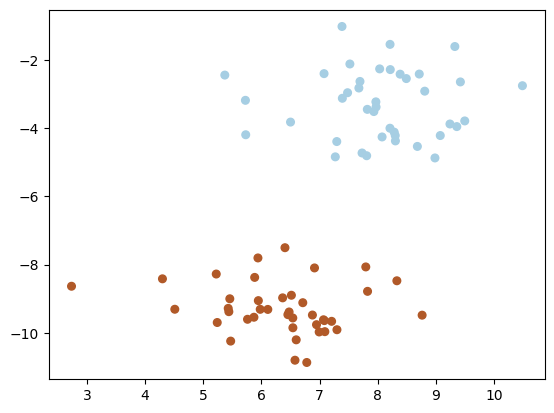

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)


In [21]:
def plot_svm(svm_, X, y):
    ax = plt.gca()
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 10)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 10)
    
    X1, X2 = np.meshgrid(xx, yy)
    Z = np.empty(X1.shape)
    for (i, j), val in np.ndenumerate(X1):
        x1 = val
        x2 = X2[i, j]
        p = svm_.decision_function([[x1, x2]])
        Z[i, j] = p[0]
    levels = [-1.0, 0.0, 1.0]
    linestyles = ["dashed", "solid", "dashed"]
    colors = "k"
    plt.contour(X1, X2, Z, levels, colors=colors, linestyles=linestyles)
    # plot support vectors
    ax.scatter(
        svm_.support_vectors_[:, 0],
        svm_.support_vectors_[:, 1],
        s=100,
        linewidth=1,
        facecolors="none",
        edgecolors="k",
    )
    plt.show()

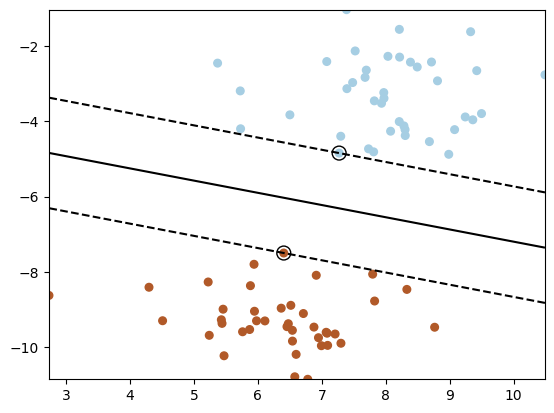

In [22]:
scikit_svm = svm.SVC(kernel='linear', C=1000)
scikit_svm.fit(X, y)
plot_svm(scikit_svm, X, y)